In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
sns.set(font_scale=1.2)

from sklearn import datasets
from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

from sklearn.metrics import classification_report,roc_curve, auc
from sklearn.preprocessing import LabelBinarizer

## scikit-learn 기본 제공 붓꽃 데이터셋 로드

In [2]:
iris = datasets.load_iris()

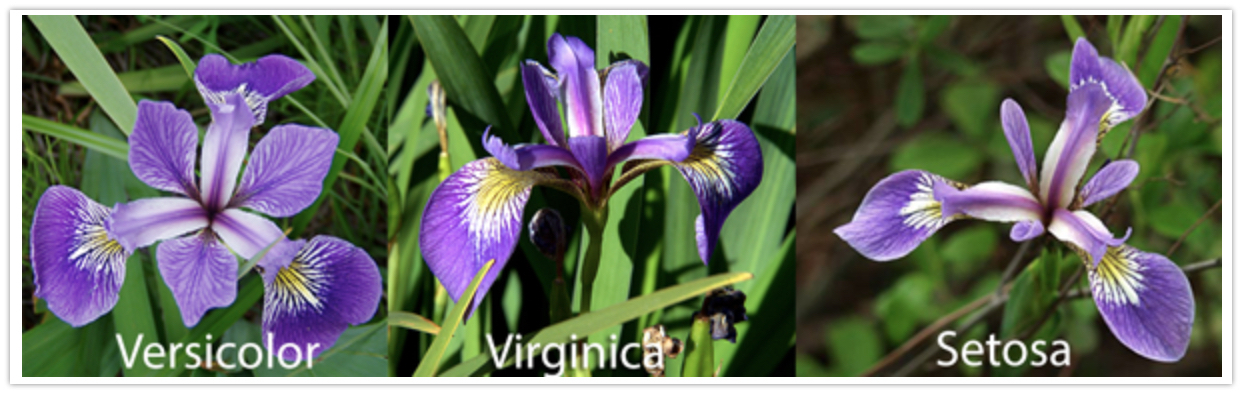

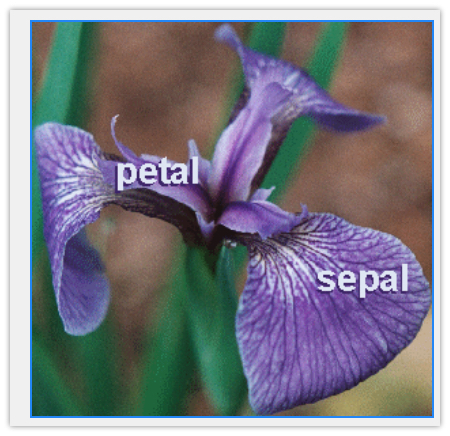

In [3]:
print(iris['DESCR'])

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

## 데이터 전처리

In [4]:
data_x = pd.DataFrame(iris['data'], columns=iris['feature_names'])

In [5]:
data_x

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


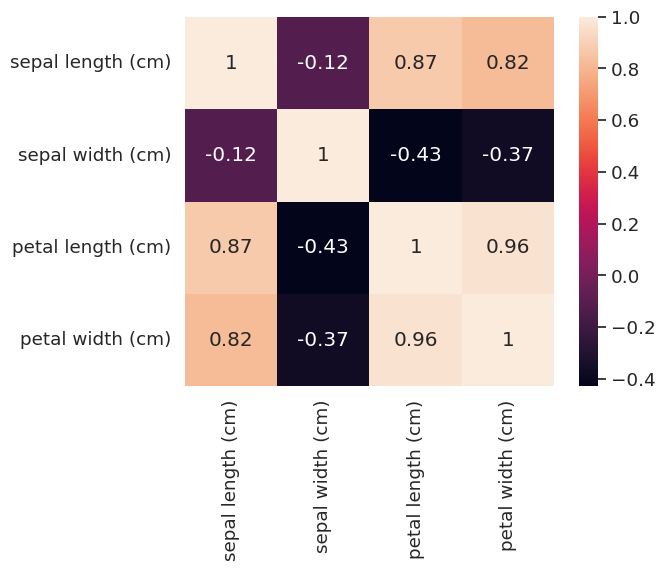

In [6]:
sns.heatmap(data=data_x.corr(), square=True, annot=True, cbar=True)
plt.show()

In [7]:
data_y = iris['target']

In [8]:
data_y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [9]:
train_x, test_x, train_y, test_y=train_test_split(data_x,data_y,test_size=0.2, shuffle=True,random_state=1,stratify=data_y)
print(train_x.shape, train_y.shape)
print(test_x.shape, test_y.shape)

(120, 4) (120,)
(30, 4) (30,)


In [10]:
LB = LabelBinarizer()
test_y_bin = LB.fit_transform(test_y)

In [11]:
test_y, test_y_bin

(array([2, 0, 1, 0, 0, 0, 2, 2, 2, 1, 0, 1, 2, 1, 2, 0, 2, 1, 1, 2, 1, 1,
        0, 0, 2, 2, 0, 0, 1, 1]),
 array([[0, 0, 1],
        [1, 0, 0],
        [0, 1, 0],
        [1, 0, 0],
        [1, 0, 0],
        [1, 0, 0],
        [0, 0, 1],
        [0, 0, 1],
        [0, 0, 1],
        [0, 1, 0],
        [1, 0, 0],
        [0, 1, 0],
        [0, 0, 1],
        [0, 1, 0],
        [0, 0, 1],
        [1, 0, 0],
        [0, 0, 1],
        [0, 1, 0],
        [0, 1, 0],
        [0, 0, 1],
        [0, 1, 0],
        [0, 1, 0],
        [1, 0, 0],
        [1, 0, 0],
        [0, 0, 1],
        [0, 0, 1],
        [1, 0, 0],
        [1, 0, 0],
        [0, 1, 0],
        [0, 1, 0]]))

## SVM 모델 학습

In [12]:
SVM = SVC(probability=True)

SVM.fit(train_x, train_y)

SVC(probability=True)

## 학습 결과 검증

In [13]:
SVM_proba = SVM.predict_proba(test_x)
SVM_pred = SVM.predict(test_x)

dftest = pd.DataFrame(np.column_stack([SVM_pred,test_y]),columns=['predict','true'])
dftest['probability'] = list(SVM_proba)

dftest

,predict,true,probability
0,2,2,"[0.010414928261039619, 0.0019272619066889288, ..."
1,0,0,"[0.9636855811461882, 0.02494952317455861, 0.01..."
2,1,1,"[0.14035109220575015, 0.8359119959706616, 0.02..."
3,0,0,"[0.9647859590258598, 0.02381737890268943, 0.01..."
4,0,0,"[0.9526221274829045, 0.033778876725623616, 0.0..."
5,0,0,"[0.9722577716550432, 0.017677394200059735, 0.0..."
6,2,2,"[0.010817776804075693, 0.013106863138967027, 0..."
7,2,2,"[0.010276359329685588, 0.050740321961694174, 0..."
8,2,2,"[0.014591274356749477, 0.25181348024847805, 0...."
9,1,1,"[0.0088563254306997, 0.7834596588739952, 0.207..."


In [14]:
print(classification_report(test_y,SVM_pred,target_names=iris.target_names))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.91      1.00      0.95        10
   virginica       1.00      0.90      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



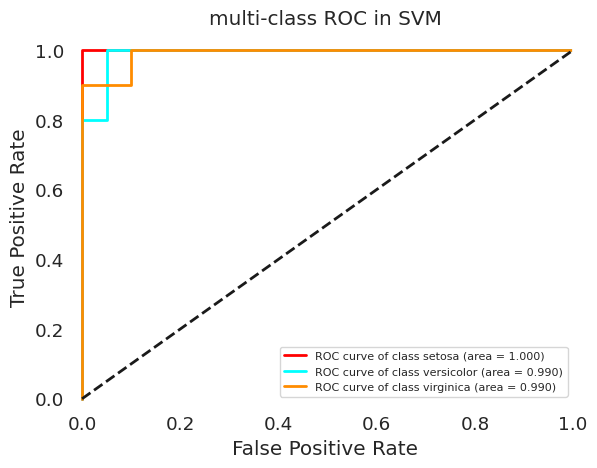

In [15]:
fpr_SVM,tpr_SVM,auc_SVM = dict(),dict(),dict()

for i in range(3):
    fpr_SVM[i], tpr_SVM[i], _ = roc_curve(test_y_bin[:, i], SVM_proba[:, i])
    auc_SVM[i] = auc(fpr_SVM[i], tpr_SVM[i])

plt.rcParams['axes.facecolor'] = 'none'
plt.figure(dpi=100)

colors = ['red','aqua', 'darkorange', 'cornflowerblue']
for i, color in zip(range(3), colors):
    plt.plot(fpr_SVM[i], tpr_SVM[i], color=color, lw=2,
             label='ROC curve of class {0} (area = {1:0.3f})'
             ''.format(iris.target_names[i], auc_SVM[i]))
plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([-0.01, 1.0])
plt.ylim([-0.01, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('multi-class ROC in SVM')
plt.legend(loc="lower right",prop={'size': 8})
plt.show()


## RandomForest Classification 학습

In [16]:
RF = RandomForestClassifier()

RF.fit(train_x, train_y)

RandomForestClassifier()

## 학습 결과 검증

In [17]:
rf_proba = RF.predict_proba(test_x)
rf_pred = RF.predict(test_x)

dftest = pd.DataFrame(np.column_stack([rf_pred,test_y]),columns=['predict','true'])
dftest['probability'] = list(rf_proba)

In [18]:
dftest

,predict,true,probability
0,2,2,"[0.0, 0.0, 1.0]"
1,0,0,"[1.0, 0.0, 0.0]"
2,1,1,"[0.01, 0.99, 0.0]"
3,0,0,"[1.0, 0.0, 0.0]"
4,0,0,"[1.0, 0.0, 0.0]"
5,0,0,"[1.0, 0.0, 0.0]"
6,2,2,"[0.0, 0.04, 0.96]"
7,2,2,"[0.0, 0.01, 0.99]"
8,2,2,"[0.0, 0.25, 0.75]"
9,1,1,"[0.0, 0.85, 0.15]"


In [19]:
print(classification_report(test_y,rf_pred,target_names=iris.target_names))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.91      1.00      0.95        10
   virginica       1.00      0.90      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



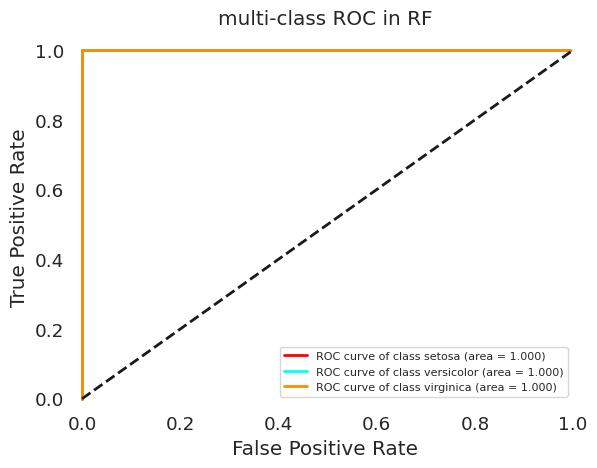

In [20]:
fpr_rf,tpr_rf,auc_rf = dict(),dict(),dict()

for i in range(3):
    fpr_rf[i], tpr_rf[i], _ = roc_curve(test_y_bin[:, i], rf_proba[:, i])
    auc_rf[i] = auc(fpr_rf[i], tpr_rf[i])

plt.rcParams['axes.facecolor'] = 'none'
plt.figure(dpi=100)

colors = ['red','aqua', 'darkorange', 'cornflowerblue']
for i, color in zip(range(3), colors):
    plt.plot(fpr_rf[i], tpr_rf[i], color=color, lw=2,
             label='ROC curve of class {0} (area = {1:0.3f})'
             ''.format(iris.target_names[i], auc_rf[i]))
plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([-0.01, 1.0])
plt.ylim([-0.01, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('multi-class ROC in RF')
plt.legend(loc="lower right",prop={'size': 8})
plt.show()


## XGBoost 모델 학습

In [21]:
XGB = XGBClassifier()

XGB.fit(train_x, train_y)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

## 학습 결과 검증

In [22]:
XGB_proba = XGB.predict_proba(test_x)
XGB_pred = XGB.predict(test_x)

dftest = pd.DataFrame(np.column_stack([XGB_pred,test_y]),columns=['predict','true'])
dftest['probability'] = list(XGB_proba)

dftest

,predict,true,probability
0,2,2,"[0.0003238052, 0.00072050135, 0.9989557]"
1,0,0,"[0.99380326, 0.0052336548, 0.00096305116]"
2,0,1,"[0.98384285, 0.014704917, 0.0014522681]"
3,0,0,"[0.99380326, 0.0052336548, 0.00096305116]"
4,0,0,"[0.99380326, 0.0052336548, 0.00096305116]"
5,0,0,"[0.99380326, 0.0052336548, 0.00096305116]"
6,2,2,"[0.00036722762, 0.0006183893, 0.9990144]"
7,2,2,"[0.00027795846, 0.0007505501, 0.99897146]"
8,2,2,"[0.014663576, 0.4204839, 0.5648526]"
9,1,1,"[0.0060502826, 0.94594926, 0.048000406]"


In [23]:
print(classification_report(test_y,XGB_pred,target_names=iris.target_names))

              precision    recall  f1-score   support

      setosa       0.91      1.00      0.95        10
  versicolor       0.90      0.90      0.90        10
   virginica       1.00      0.90      0.95        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30



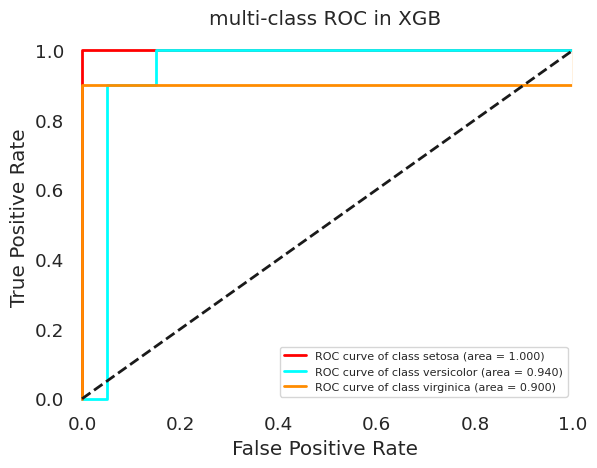

In [24]:
fpr_XGB,tpr_XGB,auc_XGB = dict(),dict(),dict()

for i in range(3):
    fpr_XGB[i], tpr_XGB[i], _ = roc_curve(test_y_bin[:, i], XGB_proba[:, i])
    auc_XGB[i] = auc(fpr_XGB[i], tpr_XGB[i])

plt.rcParams['axes.facecolor'] = 'none'
plt.figure(dpi=100)

colors = ['red','aqua', 'darkorange', 'cornflowerblue']
for i, color in zip(range(3), colors):
    plt.plot(fpr_XGB[i], tpr_XGB[i], color=color, lw=2,
             label='ROC curve of class {0} (area = {1:0.3f})'
             ''.format(iris.target_names[i], auc_XGB[i]))
plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([-0.01, 1.0])
plt.ylim([-0.01, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('multi-class ROC in XGB')
plt.legend(loc="lower right",prop={'size': 8})
plt.show()
